In [36]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings("ignore")

In [37]:
os.path.exists('/content/Walmart DataSet.csv')

True

In [70]:
try:
    df = pd.read_csv('/content/Walmart DataSet.csv')
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    df = df.sort_values(by=['Store', 'Date'])
except FileNotFoundError:
    print("Error: 'walmart.csv' not found. Please ensure the file is in the correct directory.")

In [71]:
df.head(5)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [72]:
unemp_corr = df.groupby('Store')[['Weekly_Sales', 'Unemployment']].corr().iloc[0::2, -1]
print("Stores where Unemployment negatively impacts sales the most:")
print(unemp_corr.sort_values().head(5))

Stores where Unemployment negatively impacts sales the most:
Store              
38     Weekly_Sales   -0.785290
44     Weekly_Sales   -0.780076
39     Weekly_Sales   -0.384681
42     Weekly_Sales   -0.356355
41     Weekly_Sales   -0.350630
Name: Unemployment, dtype: float64


In [95]:
df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()
monthly_sales

,Weekly_Sales
Month,
1,9.238846e+05
2,1.053200e+06
3,1.013309e+06
4,1.026762e+06
5,1.031714e+06
6,1.064325e+06
7,1.031748e+06
8,1.048017e+06
9,9.893353e+05


In [96]:
temp_corr = df['Weekly_Sales'].corr(df['Temperature'])
print(f"Overall Correlation between Temperature and Weekly Sales: {temp_corr:.4f}")

Overall Correlation between Temperature and Weekly Sales: -0.0638


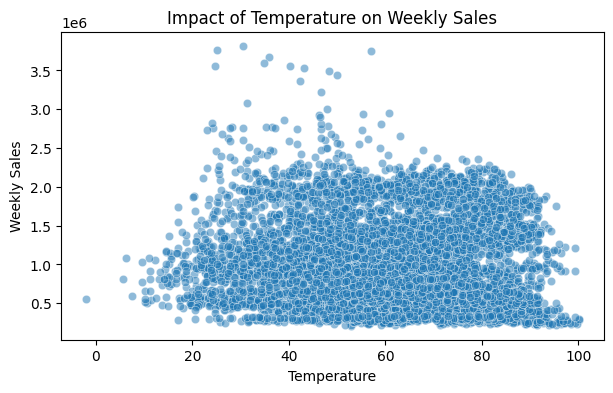

In [97]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='Temperature', y='Weekly_Sales', alpha=0.5)
plt.title('Impact of Temperature on Weekly Sales')
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')
plt.show()

In [98]:
print(f"Correlation of Sales with Temperature: {df['Weekly_Sales'].corr(df['Temperature']):.4f}")
print(f"Correlation of Sales with CPI: {df['Weekly_Sales'].corr(df['CPI']):.4f}")

Correlation of Sales with Temperature: -0.0638
Correlation of Sales with CPI: -0.0726


In [99]:
store_cpi_analysis = df.groupby('Store')[['Weekly_Sales', 'CPI']].corr().iloc[0::2, 1]
print("\nCPI Correlation with Sales for first 5 stores:")
print(store_cpi_analysis.head(5))


CPI Correlation with Sales for first 5 stores:
Store              
1      Weekly_Sales    0.225408
2      Weekly_Sales   -0.062431
3      Weekly_Sales    0.317250
4      Weekly_Sales    0.351157
5      Weekly_Sales    0.308261
Name: CPI, dtype: float64


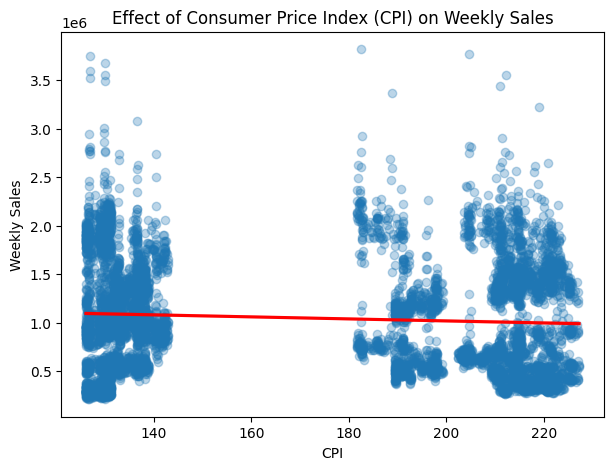

In [100]:
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='CPI', y='Weekly_Sales', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Effect of Consumer Price Index (CPI) on Weekly Sales')
plt.xlabel('CPI')
plt.ylabel('Weekly Sales')
plt.show()

In [101]:
#Top performing stores according to the historical data.
top_stores = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
top_stores.head(6)

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08
10,2.716177e+08


In [102]:
print(f"Top Performing Store: {top_stores.index[0]} (Sales: {top_stores.iloc[0]})")
print(f"Top Performing Store: {top_stores.index[0]} (Sales: {top_stores.iloc[0]})")
print(f"Worst Performing Store: {top_stores.index[-1]} (Sales: {top_stores.iloc[-1]})")
print(f"Difference: {top_stores.iloc[0] - top_stores.iloc[-1]}")

Top Performing Store: 20 (Sales: 301397792.46)
Top Performing Store: 20 (Sales: 301397792.46)
Worst Performing Store: 33 (Sales: 37160221.96)
Difference: 264237570.49999997


**PREDICTIVE ANALYSIS (SARIMA for 5 Stores)**

In [103]:
top_5_stores = top_stores.head(5).index.tolist()
print(f"\nStarting 12-week forecast for Stores: {top_5_stores}")


Starting 12-week forecast for Stores: [20, 4, 14, 13, 2]


In [104]:
def run_sarima_forecast(store_id):
    store_df = df[df['Store'] == store_id][['Date', 'Weekly_Sales']]
    store_df.set_index('Date', inplace=True)
    store_df = store_df.resample('W').sum()


    model = SARIMAX(store_df['Weekly_Sales'],
                    order=(1, 1, 1),
                    seasonal_order=(1, 1, 1, 52),
                    enforce_stationarity=False,
                    enforce_invertibility=False)

    model_fit = model.fit(disp=False)
    forecast = model_fit.get_forecast(steps=12)
    return forecast.predicted_mean

In [105]:
for store in top_5_stores:
    forecast_results = run_sarima_forecast(store)
    print(f"\n--- Forecast for Store {store} (Next 12 Weeks) ---")
    print(forecast_results)


--- Forecast for Store 20 (Next 12 Weeks) ---
2012-11-04    2.322377e+06
2012-11-11    2.315227e+06
2012-11-18    2.217460e+06
2012-11-25    2.949935e+06
2012-12-02    2.364469e+06
2012-12-09    2.620427e+06
2012-12-16    2.821845e+06
2012-12-23    3.629009e+06
2012-12-30    2.073027e+06
2013-01-06    2.006806e+06
2013-01-13    1.963163e+06
2013-01-20    1.936039e+06
Freq: W-SUN, Name: predicted_mean, dtype: float64

--- Forecast for Store 4 (Next 12 Weeks) ---
2012-11-04    2.234833e+06
2012-11-11    2.188990e+06
2012-11-18    2.239716e+06
2012-11-25    2.882253e+06
2012-12-02    2.204374e+06
2012-12-09    2.453441e+06
2012-12-16    2.731373e+06
2012-12-23    3.485104e+06
2012-12-30    2.015193e+06
2013-01-06    2.058154e+06
2013-01-13    1.996752e+06
2013-01-20    2.039841e+06
Freq: W-SUN, Name: predicted_mean, dtype: float64

--- Forecast for Store 14 (Next 12 Weeks) ---
2012-11-04    1.760254e+06
2012-11-11    1.724399e+06
2012-11-18    1.638928e+06
2012-11-25    2.232732e+06
2012